# Significance/p-value calculation

This tutorial shows how to calculate the significance (local p-value).

For analysis setup details check the [Fitting a steady point-source with the public 14-year IceCube track data](fitting_a_source.ipynb) tutorial.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import skyllh
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis
from skyllh.core.config import Config
from skyllh.core.source_model import PointLikeSource

cfg = Config()

datasets = skyllh.create_datasets('IceTracks-DR2', cfg=cfg)

src_ra = 77.35  # degrees
src_dec = 5.7  # degrees

source = PointLikeSource(ra=np.radians(src_ra), dec=np.radians(src_dec))

ana = create_analysis(cfg=cfg, datasets=datasets, source=source)

100%|██████████| 136/136 [00:00<00:00, 9782.30it/s]


Initializing the analysis instance and unblinding the data.

In [2]:
from skyllh.core.random import RandomStateService

rss = RandomStateService(3090)
ts, fitparam_values, status = ana.unblind(rss)
ns_bf = fitparam_values['ns']
gamma_bf = fitparam_values['gamma']
print(f'Unblinded results: TS={ts:.2f}, ns={ns_bf:.2f}, gamma={gamma_bf:.2f}')
print(f'Minimizer status: {status}')

Unblinded results: TS=9.77, ns=8.80, gamma=1.97
Minimizer status: {'grad': array([-3.66069501e-06,  5.61787954e-05]), 'task': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'funcalls': 16, 'nit': 11, 'warnflag': 0, 'skyllh_minimizer_n_reps': 0, 'n_llhratio_func_calls': 16}


## Calculating the significance (local p-value) by generating the test-statistic distribution of background-only data trials

The significance of the source, i.e. the local p-value, can be calculated by generating the test-statistic distribution of background-only data trials, i.e. for zero injected signal events. SkyLLH provides the helper function ``create_trial_data_file`` to do that:

In [3]:
from skyllh.core.utils.analysis import create_trial_data_file

In [4]:
help(create_trial_data_file)

Help on function create_trial_data_file in module skyllh.core.utils.analysis:

create_trial_data_file(
    ana,
    rss,
    n_trials,
    mean_n_sig=0,
    mean_n_sig_null=0,
    mean_n_bkg_list=None,
    minimizer_rss=None,
    bkg_kwargs=None,
    sig_kwargs=None,
    pathfilename=None,
    ncpu=None,
    ppbar=None,
    tl=None
)
    Creates and fills a trial data file with `n_trials` generated trials for
    each mean number of injected signal events specified by `mean_n_sig` for a
    given analysis.

    Parameters
    ----------
    ana : instance of Analysis
        The Analysis instance to use for the trial generation.
    rss : instance of RandomStateService
        The RandomStateService instance to use for generating random
        numbers.
    n_trials : int
        The number of trials to perform for each hypothesis test.
    mean_n_sig : ndarray of float | float | 2- or 3-element sequence of float
        The array of mean number of injected signal events (MNOISEs) for 

In [5]:
from skyllh.core.timing import TimeLord

tl = TimeLord()

In [6]:
rss = RandomStateService(seed=1)
(_, _, _, trials) = create_trial_data_file(
    ana=ana, rss=rss, n_trials=1e3, mean_n_sig=0, pathfilename='txs_bkg_trails.npy', ncpu=8, tl=tl
)
print(tl)

100%|██████████| 1001/1001 [00:19<00:00, 51.26it/s]

TimeLord: Executed tasks:
[Generating background events for dataset "IC40".     ] 6.9e-04 sec/iter (1000)
[Generating background events for dataset "IC59".     ]   0.002 sec/iter (1000)
[Generating background events for dataset "IC79".     ]   0.001 sec/iter (1000)
[Generating background events for dataset "IC86_I-XI".]   0.008 sec/iter (1000)
[Generating pseudo data.                              ]   0.010 sec/iter (1000)
[Initializing trial.                                  ]   0.019 sec/iter (1000)
[Get sig probability densities and grads.             ] 1.0e-06 sec/iter (88160)
[Get bkg probability densities and grads.             ] 7.8e-07 sec/iter (88160)
[Calculate PDF ratios.                                ] 4.6e-05 sec/iter (88160)
[Calc pdfratio value Ri                               ] 3.5e-04 sec/iter (44080)
[Calc logLambda and grads                             ] 1.1e-04 sec/iter (44080)
[Evaluate llh-ratio function.                         ]   0.002 sec/iter (11020)
[Minimiz

After generating the background trials, we can histogram the test-statistic values and plot the TS distribution.

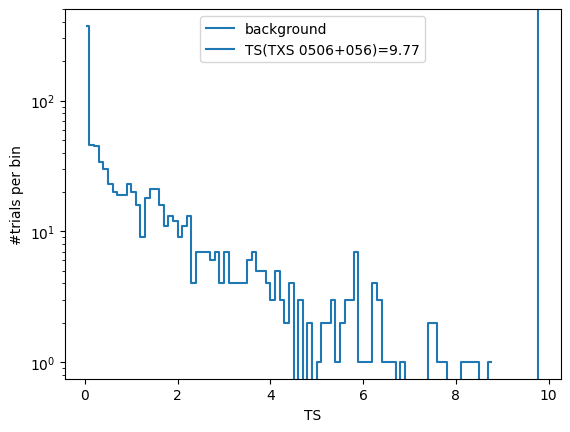

In [7]:
fig, ax = plt.subplots()
(h, be) = np.histogram(trials['ts'], bins=np.arange(0, np.max(trials['ts']) + 0.1, 0.1))
ax.plot(0.5 * (be[:-1] + be[1:]), h, drawstyle='steps-mid', label='background')
ax.axvline(ts, label=f'TS(TXS 0506+056)={ts:.2f}')
ax.set_yscale('log')
ax.set_xlabel('TS')
ax.set_ylabel('#trials per bin')
ax.legend()
plt.show()

One can also use a helper function ``extend_trial_data_file`` to extend the trial data if the trial data generated is not enough to estimate the p-value reliably. 

It is also possible to write these trials onto a file, by defining a file path in the function. 

In [8]:
from skyllh.core.utils.analysis import extend_trial_data_file

In [9]:
help(extend_trial_data_file)

Help on function extend_trial_data_file in module skyllh.core.utils.analysis:

extend_trial_data_file(
    ana,
    rss,
    n_trials,
    trial_data,
    mean_n_sig=0,
    mean_n_sig_null=0,
    mean_n_bkg_list=None,
    bkg_kwargs=None,
    sig_kwargs=None,
    pathfilename=None,
    **kwargs
)
    Appends to the trial data file `n_trials` generated trials for each
    mean number of injected signal events specified by `mean_n_sig` for a
    given analysis.

    Parameters
    ----------
    ana : instance of Analysis
        The Analysis instance to use for sensitivity estimation.
    rss : instance of RandomStateService
        The RandomStateService instance to use for generating random
        numbers.
    n_trials : int
        The number of trials the trial data file needs to be extended by.
    trial_data : structured numpy ndarray
        The structured numpy ndarray holding the trials.
    mean_n_sig : ndarray of float | float | 2- or 3-element sequence of float
        The 

In [10]:
tl = TimeLord()
rss = RandomStateService(seed=2)
trials = extend_trial_data_file(
    ana=ana, rss=rss, n_trials=4e3, trial_data=trials, pathfilename='txs_bkg_trails.npy', ncpu=8, tl=tl
)

100%|██████████| 4001/4001 [01:14<00:00, 54.02it/s]


In [11]:
print(tl)

TimeLord: Executed tasks:
[Generating background events for dataset "IC40".     ] 6.6e-04 sec/iter (4000)
[Generating background events for dataset "IC59".     ]   0.001 sec/iter (4000)
[Generating background events for dataset "IC79".     ]   0.001 sec/iter (4000)
[Generating background events for dataset "IC86_I-XI".]   0.008 sec/iter (4000)
[Generating pseudo data.                              ]   0.010 sec/iter (4000)
[Initializing trial.                                  ]   0.016 sec/iter (4000)
[Get sig probability densities and grads.             ] 1.0e-06 sec/iter (357352)
[Get bkg probability densities and grads.             ] 8.0e-07 sec/iter (357352)
[Calculate PDF ratios.                                ] 4.6e-05 sec/iter (357352)
[Calc pdfratio value Ri                               ] 3.1e-04 sec/iter (178676)
[Calc logLambda and grads                             ] 1.1e-04 sec/iter (178676)
[Evaluate llh-ratio function.                         ]   0.001 sec/iter (44669)
[Mi

``skyllh.core.utils.analysis`` has a function ``calculate_pval_from_trials`` that allows one to calculate the p_value from trials. The function takes the created trials and the critical TS value to give the computed p_value and the error on it. 

In [12]:
from skyllh.core.utils.analysis import calculate_pval_from_trials

In [13]:
help(calculate_pval_from_trials)

Help on function calculate_pval_from_trials in module skyllh.core.utils.analysis:

calculate_pval_from_trials(ts_vals, ts_threshold, comp_operator='greater_equal')
    Calculates the percentage (p-value) of test-statistic trials that are
    above the given test-statistic critical value.
    In addition it calculates the standard deviation of the p-value assuming
    binomial statistics.

    Parameters
    ----------
    ts_vals : (n_trials,)-shaped 1D ndarray of float
        The ndarray holding the test-statistic values of the trials.
    ts_threshold : float
        The critical test-statistic value.
    comp_operator: string, optional
        The comparison operator for p-value calculation. It can be set to one of
        the following options: 'greater' or 'greater_equal'.

    Returns
    -------
    p, p_sigma: tuple(float, float)



In [14]:
trials_ts_dis = np.load('txs_bkg_trails.npy')

In [15]:
p_val_from_trials, p_val_from_trials_sigma = calculate_pval_from_trials(trials_ts_dis['ts'], ts)
print(f'p_value calculated from trials: {p_val_from_trials:.3e}')

p_value calculated from trials: 2.200e-03


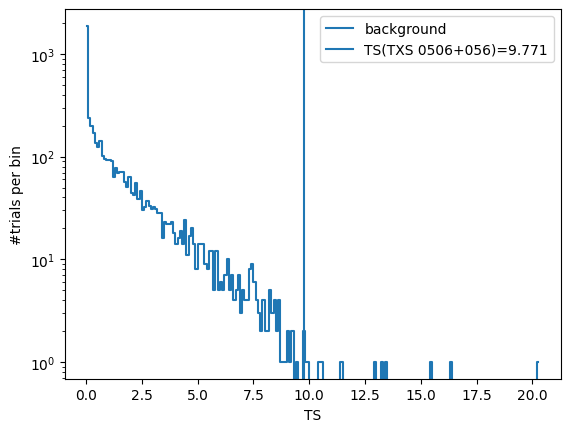

In [16]:
fig, ax = plt.subplots()
(h, be) = np.histogram(trials_ts_dis['ts'], bins=np.arange(0, np.max(trials_ts_dis['ts']) + 0.1, 0.1))
ax.plot(0.5 * (be[:-1] + be[1:]), h, drawstyle='steps-mid', label='background')
ax.axvline(ts, label=f'TS(TXS 0506+056)={ts:.3f}')
ax.set_yscale('log')
ax.set_xlabel('TS')
ax.set_ylabel('#trials per bin')
ax.legend()
plt.show()

## Calculating the significance (local p-value) by fitting a truncated gamma function

To estimate the significance of the result, one can use the ``do_trials`` property of the ``Analysis`` instance. This function generates some pseudo-experiments which are background only hypothesis with no signal. 

In [17]:
help(ana.do_trials)

Help on method do_trials in module skyllh.core.analysis:

do_trials(rss, n, ncpu=None, tl=None, ppbar=None, **kwargs) method of skyllh.core.analysis.SingleSourceMultiDatasetLLHRatioAnalysis instance
    Executes the :meth:`do_trial` method ``n`` times with possible
    multi-processing.

    Parameters
    ----------
    rss : instance of RandomStateService
        The RandomStateService instance to use for generating random
        numbers.
    n : int
        Number of trials to generate using the `do_trial` method.
    ncpu : int | None
        The number of CPUs to use, i.e. the number of subprocesses to
        spawn. If set to None, the global setting will be used.
    tl : instance of TimeLord | None
        The optional instance of TimeLord that should be used to time
        individual tasks.
    ppbar : instance of ProgressBar | None
        The possible parent ProgressBar instance.
    **kwargs
        Additional keyword arguments are passed to the :meth:`do_trial`
        m

In [18]:
trials = ana.do_trials(
    rss=rss,
    n=1000,
)

100%|██████████| 1000/1000 [01:25<00:00, 11.76it/s]


``extend_trial_data_file`` is a helper function that allows one to add more trial data to better calculate the p-value. This helper function used here is separate from the ``do_trials`` property of the analysis instance. 

In [19]:
from skyllh.core.utils.analysis import extend_trial_data_file

trials = extend_trial_data_file(ana=ana, rss=rss, n_trials=1000, trial_data=trials)

100%|██████████| 1001/1001 [01:25<00:00, 11.70it/s]


We can have a look at the distributions of the trial results and compare it to the unblinded result.

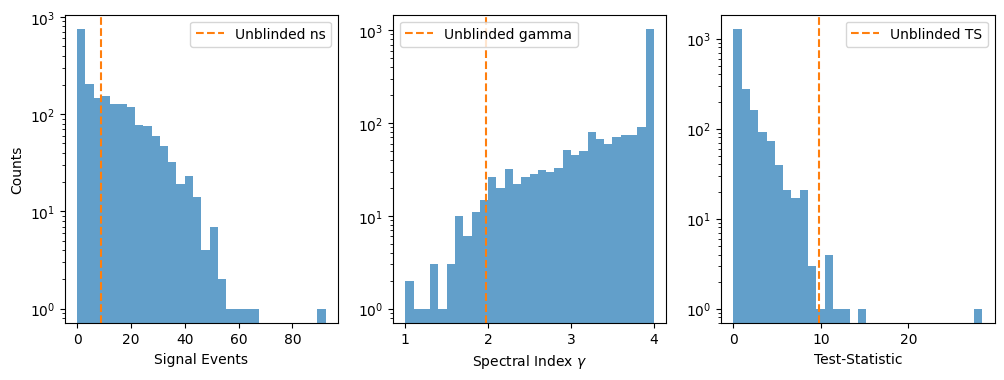

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(trials['ns'], bins=30, color='C0', alpha=0.7)
ax[0].axvline(ns_bf, color='C1', linestyle='--', label='Unblinded ns')
ax[0].legend()
ax[0].set_yscale('log')
ax[0].set_ylabel(r'Counts')
ax[0].set_xlabel(r'Signal Events')

ax[1].hist(trials['gamma'], bins=30, color='C0', alpha=0.7)
ax[1].axvline(gamma_bf, color='C1', linestyle='--', label='Unblinded gamma')
ax[1].legend()
ax[1].set_yscale('log')
ax[1].set_xlabel(r'Spectral Index $\gamma$')

ax[2].hist(trials['ts'], bins=30, color='C0', alpha=0.7)
ax[2].axvline(ts, color='C1', linestyle='--', label='Unblinded TS')
ax[2].legend()
ax[2].set_yscale('log')
ax[2].set_xlabel('Test-Statistic')
plt.show()

### Estimating the p-value for the result, via fitting the Test Statistic (TS) distribution with a truncated gamma function

The ``fit_truncated_gamma`` function can be used to fit the truncated gamma function to the TS distribution. 

The ``calucate_pval_from_trials_mixed`` function, allows us to estimate the p-value from the fit. This function can also be used to estimate the p-value for very high TS values.

In [21]:
from scipy.stats import gamma

from skyllh.core.utils.analysis import (
    calculate_critical_ts_from_gamma,
    calculate_pval_from_trials_mixed,
    fit_truncated_gamma,
)

In [22]:
help(calculate_pval_from_trials_mixed)

Help on function calculate_pval_from_trials_mixed in module skyllh.core.utils.analysis:

calculate_pval_from_trials_mixed(
    ts_vals,
    ts_threshold,
    switch_at_ts=3.0,
    eta=None,
    n_max=500000,
    comp_operator='greater_equal'
)
    Calculates the probability (p-value) of test-statistic exceeding
    the given test-statistic threshold. This calculation relies on fitting
    a gamma distribution to a list of ts values if ts_threshold is larger than
    switch_at_ts. If ts_threshold is smaller then the pvalue will be taken
    from the trials directly.

    Parameters
    ----------
    ts_vals : (n_trials,)-shaped 1D ndarray of float
        The ndarray holding the test-statistic values of the trials.
    ts_threshold : float
        The critical test-statistic value.
    switch_at_ts : float, optional
        Test-statistic value below which p-value is computed from trials
        directly. For thresholds greater than switch_at_ts the pvalue is
        calculated using a

You need to truncate the distribution at some $\eta > 0$ because the TS distribution is the sum of a delta peak at 0
and a continuous distribution for TS > 0.

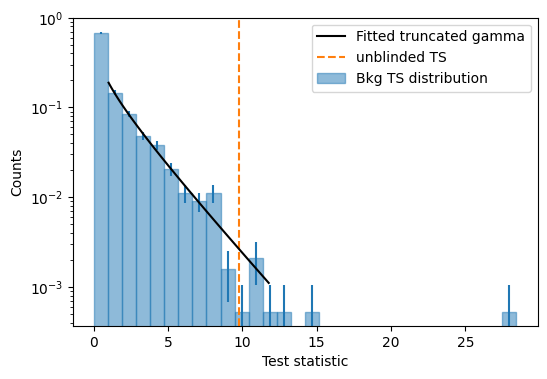

In [23]:
eta = 1.0
pars, norm = fit_truncated_gamma(trials['ts'], eta=eta)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
counts, bins = np.histogram(trials['ts'], bins=30, density=True)
ax.bar(
    0.5 * (bins[1:] + bins[:-1]),
    height=counts,
    width=bins[1:] - bins[:-1],
    edgecolor='C0',
    color='C0',
    alpha=0.5,
    label='Bkg TS distribution',
)
ax.errorbar(
    0.5 * (bins[1:] + bins[:-1]),
    counts,
    yerr=np.sqrt(counts / len(trials['ts']) / (bins[1:] - bins[:-1])),
    fmt='',
    ls='',
    color='C0',
)
bins = bins[bins > eta]
bincenters = 0.5 * (bins[1:] + bins[:-1])
bw = bins[1:] - bins[:-1]
ax.set_yscale('log')

vals = np.linspace(eta, ts + 2, 100)
ax.plot(
    vals, norm * gamma.pdf(vals, a=pars[0], scale=pars[1]), lw=1.5, color='k', zorder=5, label='Fitted truncated gamma'
)

ax.axvline(ts, color='C1', linestyle='--', label='unblinded TS')

ax.set_xlabel('Test statistic')
ax.set_ylabel('Counts')

ax.legend()
plt.show()

``calculate_critical_ts_from_gamma`` function calculates the TS you would need in your analysis to reach a given significance.

In [24]:
critical_ts = calculate_critical_ts_from_gamma(
    ts=trials['ts'],
    h0_ts_quantile=1.3e-3,  # this is ~ 3 sigma
    eta=1.0,
)
print(f'TS value for a 3 sigma detection: {critical_ts:.2f}')
critical_ts = calculate_critical_ts_from_gamma(
    ts=trials['ts'],
    h0_ts_quantile=2.9e-7,  # this is ~ 5 sigma
    eta=1.0,
)
print(f'TS value for a 5 sigma detection: {critical_ts:.2f}')

TS value for a 3 sigma detection: 13.36
TS value for a 5 sigma detection: 33.38


Finally, here the significance of the unblinded result can be obtained. 

In [25]:
pval, _ = calculate_pval_from_trials_mixed(ts_vals=trials['ts'], ts_threshold=ts, eta=eta)
print(f'Unblinded result p-value by fitting the truncated gamma function: {pval:.2e}')

Unblinded result p-value by fitting the truncated gamma function: 6.10e-03


In [26]:
print(f'p-value from TS distribution: {p_val_from_trials:.2e}')

p-value from TS distribution: 2.20e-03


The p-value calculated using both methods are compatible. 



In [27]:
print(f'The error in calculating p-value from trials: {p_val_from_trials_sigma:.2e}')

The error in calculating p-value from trials: 6.63e-04
